In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import optimize, signal, special
from sklearn import metrics
from sklearn.linear_model import LinearRegression

$$\mathrm{A \underset{Ni}{\overset{k_1}{\longrightarrow}} B + C}$$

$$r = k_1 \theta_A = k_1\frac{aA}{1 + aA + bB + cC}$$

$$r = \frac{1}{V}\frac{\mathrm{d}\xi}{\mathrm{d}t} \simeq k_1\frac{aA}{aA + bB} = k_1\frac{a(n_0 - \xi)}{a(n_0 - \xi) + b\xi}$$

$$\int\limits_0^\xi\left(1 + \frac{b\xi}{a(n_0-\xi)}\right)\mathrm{d}\xi = \int\limits_0^t k_1V\mathrm{d}t$$

$$\left(1 - k_2\right)\xi - n_0 k_2\ln\left|\frac{n_0 - \xi}{n_0}\right| = k_1Vt$$

$$ t(\xi) = \frac{1}{k_1}(1-k_2) \frac{\xi}{V} + \frac{k_2}{k_1}\left(-\frac{n_0}{V}\right)\ln\left|\frac{n_0 - \xi}{n_0}\right| = c_1 x_1(\xi) + c_2 x_2(\xi)$$

$$k_1 = \frac{1}{c_1 + c_2} \,,\quad k_2 = \frac{c_2}{c_1 + c_2}$$

$$r = k_1\frac{aA}{aA + bB} \rightarrow \frac{1}{r} = \frac{1}{k_1}\left(1 + k_2 \frac{\xi}{n_0 - \xi}\right) $$


$$
\begin{align}
(1 - k_2) \xi - n_0 k_2 \ln\left(\frac{n_0 - \xi}{n_0}\right) &= k_1 V t \\
\Leftrightarrow -\frac{1 - k_2}{n_0 k_2}\xi + \ln\left(\frac{n_0 - \xi}{n_0}\right) &= - \frac{k_1 V t}{n_0 k_2} \\
\Leftrightarrow -\frac{1 - k_2}{n_0 k_2}\xi + \frac{1 - k_2}{k_2} + \ln\left(\frac{n_0 - \xi}{n_0}\right) &= - \frac{k_1 V t}{n_0 k_2} + \frac{1 - k_2}{k_2} \\
\Leftrightarrow \frac{1 - k_2}{k_2}\frac{n_0 - \xi}{n_0} + \ln\left(\frac{n_0 - \xi}{n_0}\right) &= - \frac{k_1 V t}{n_0 k_2} + \frac{1 - k_2}{k_2} \\
\Leftrightarrow \exp\left(\frac{1 - k_2}{k_2}\frac{n_0 - \xi}{n_0}\right)\frac{n_0 - \xi}{n_0} &= \exp\left(- \frac{k_1 V t}{n_0 k_2} + \frac{1 - k_2}{k_2}\right) \\
\Leftrightarrow \exp\left(\frac{1 - k_2}{k_2}\frac{n_0 - \xi}{n_0}\right)\frac{1 - k_2}{k_2}\frac{n_0 - \xi}{n_0} &= \frac{1 - k_2}{k_2}\exp\left(- \frac{k_1 V t}{n_0 k_2} + \frac{1 - k_2}{k_2}\right) \\
\Leftrightarrow \frac{1 - k_2}{k_2}\frac{n_0 - \xi}{n_0} &= W_0\left[\frac{1 - k_2}{k_2}\exp\left(- \frac{k_1 V t}{n_0 k_2} + \frac{1 - k_2}{k_2}\right)\right] \\
\Leftrightarrow \frac{n_0 - \xi}{n_0} &= \frac{k_2}{1 - k_2}W_0\left[\frac{1 - k_2}{k_2}\exp\left(- \frac{k_1 V t}{n_0 k_2} + \frac{1 - k_2}{k_2}\right)\right] \\
\Leftrightarrow \xi &= n_0 \left( 1 - \frac{k_2}{1 - k_2}W_0\left[\frac{1 - k_2}{k_2}\exp\left(- \frac{k_1 V t}{n_0 k_2} + \frac{1 - k_2}{k_2}\right)\right] \right) \\
\end{align}
$$

In [2]:
results = []

### Load data

In [3]:
df = pd.read_csv("cathet.csv")
df

,t,V
0,0,0.000000
1,39,0.000008
2,131,0.000027
3,184,0.000038
4,214,0.000044
...,...,...
111,6938,0.000927
112,7088,0.000943
113,7272,0.000960
114,7300,0.000963


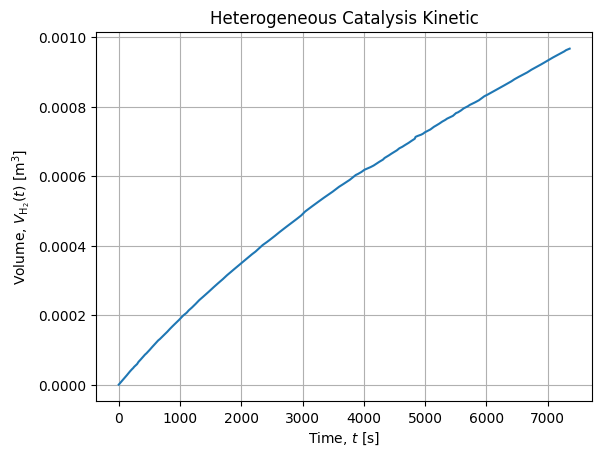

In [4]:
fig, axe = plt.subplots()
axe.plot(df["t"], df["V"])
axe.set_title("Heterogeneous Catalysis Kinetic")
axe.set_xlabel("Time, $t$ $[\mathrm{s}]$")
axe.set_ylabel("Volume, $V_\mathrm{H_2}(t)$ $[\mathrm{m^3}]$")
axe.grid()

In [5]:
R = 8.31446261815324           # J/mol.K
T0 = 292.05                    # K
p0 = 101600                    # Pa
V = 190e-6                     # m3 of isopropanol
m = 2.7677                     # g of Raney Nickel
rho = 785                      # kg/m³
M = 60.1                       # g/mol
n0 = 1000 * rho * V / M        # mol

In [6]:
n0

2.4816971713810316

In [7]:
df["xi"] = p0 * df["V"] / (R * T0)

In [8]:
df["x1"] = df["xi"] / V
df["x2"] = - (n0 / V) * np.log((n0 - df["xi"]) / n0)

In [9]:
df["B/A"] = df["xi"] / (n0 - df["xi"])
df["dxidt1"] = df["xi"].diff() / df["t"].diff()
df["1/r1"] = V / df["dxidt1"]

In [10]:
df

,t,V,xi,x1,x2,B/A,dxidt1,1/r1
0,0,0.000000,0.000000,0.000000,-0.000000,0.000000,NaN,NaN
1,39,0.000008,0.000339,1.783749,1.783871,0.000137,0.000009,21.864063
2,131,0.000027,0.001126,5.923808,5.925152,0.000454,0.000009,22.221904
3,184,0.000038,0.001603,8.434270,8.436994,0.000646,0.000009,21.111656
4,214,0.000044,0.001845,9.711522,9.715134,0.000744,0.000008,23.487920
...,...,...,...,...,...,...,...,...
111,6938,0.000927,0.038791,204.162179,205.774609,0.015879,0.000004,44.353932
112,7088,0.000943,0.039439,207.575526,209.242616,0.016149,0.000004,43.945140
113,7272,0.000960,0.040172,211.429304,213.159215,0.016453,0.000004,47.745348
114,7300,0.000963,0.040314,212.178039,213.920291,0.016513,0.000005,37.396452


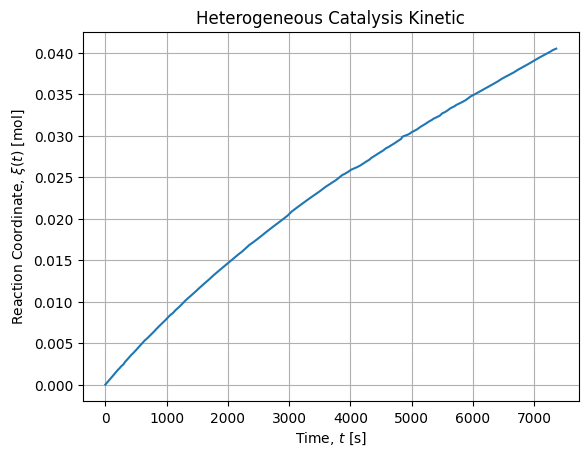

In [11]:
fig, axe = plt.subplots()
axe.plot(df["t"], df["xi"])
axe.set_title("Heterogeneous Catalysis Kinetic")
axe.set_xlabel(r"Time, $t$ $[\mathrm{s}]$")
axe.set_ylabel(r"Reaction Coordinate, $\xi(t)$ $[\mathrm{mol}]$")
axe.grid()

### NLLS w/ Analytical Solution

In [12]:
def model1(t, k1, k2):
    return np.real(n0 * (1 - k2 / (1 - k2) * special.lambertw((1 - k2) / k2 * np.exp(- k1 * V * t / (n0 * k2) + (1 - k2) / k2))))

In [13]:
popt1, pcov1 = optimize.curve_fit(model1, df["t"], df["xi"], p0=[1e-2, 100])
popt1, pcov1

(array([4.74055853e-02, 7.73469604e+01]),
 array([[1.03016125e-08, 5.13022024e-05],
        [5.13022024e-05, 2.64738605e-01]]))

In [14]:
sp1 = np.sqrt(np.diag(pcov1))
sp1

array([1.01496860e-04, 5.14527555e-01])

In [15]:
df["xi1"] = model1(df["t"], *popt1)

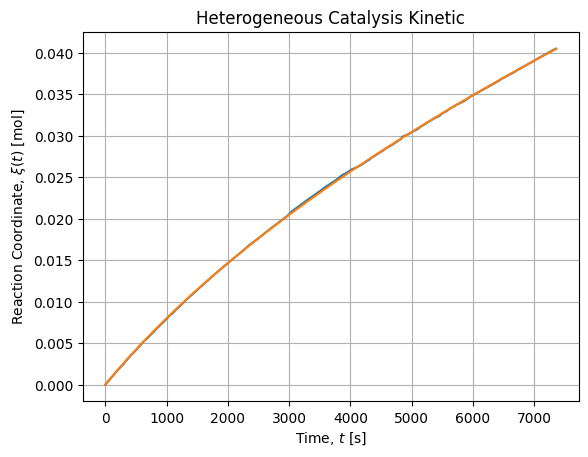

In [16]:
fig, axe = plt.subplots()
axe.plot(df["t"], df["xi"])
axe.plot(df["t"], df["xi1"])
axe.set_title("Heterogeneous Catalysis Kinetic")
axe.set_xlabel(r"Time, $t$ $[\mathrm{s}]$")
axe.set_ylabel(r"Reaction Coordinate, $\xi(t)$ $[\mathrm{mol}]$")
axe.grid()

In [17]:
score1 = metrics.r2_score(df["xi"], df["xi1"])
score1

0.9999564205718714

In [18]:
chi21 = np.sum(((df["xi"] - df["xi1"]) / df["xi1"]) ** 2)
chi21

np.float64(1.0089353058130162)

In [19]:
results.append({
    "name": "NLLS Model",
    "k1": popt1[0],
    "k2": popt1[1],
    "r2": score1,
    "chi2": chi21
})

### NLLS reversed

In [20]:
def model2(xi, k1, k2):
    return (1 - k2 ) / k1 * (xi / V) - (k2 / k1) * (n0 / V) * np.log((n0 - xi) / n0)

In [21]:
popt2, pcov2 = optimize.curve_fit(model2, df["xi"], df["t"])
popt2, pcov2

(array([4.75360720e-02, 7.80055915e+01]),
 array([[1.21264765e-08, 5.87170347e-05],
        [5.87170347e-05, 2.90823564e-01]]))

In [22]:
sp2 = np.sqrt(np.diag(pcov2))
sp2

array([1.10120282e-04, 5.39280599e-01])

In [23]:
df["xi2"] = model1(df["t"], *popt2)

In [24]:
score2 = metrics.r2_score(df["xi"], df["xi2"])
score2

0.999955784389951

In [25]:
chi22 = np.sum(((df["xi"] - df["xi2"]) / df["xi2"]) ** 2)
chi22

np.float64(1.0107493261069072)

In [26]:
results.append({
    "name": "NLLS Reversed Model",
    "k1": popt2[0],
    "k2": popt2[1],
    "r2": score2,
    "chi2": chi22
})

### OLS reversed

In [27]:
X3 = df[["x1", "x2"]].values
y3 = df["t"].values

In [28]:
OLS3 = LinearRegression(fit_intercept=False).fit(X3, y3)

In [29]:
def solveOLS3(c1, c2):
    k1 = 1. / (c1 + c2)
    k2 = c2 * k1
    return np.array([k1, k2])

In [30]:
popt3 = solveOLS3(*OLS3.coef_)

In [31]:
popt3

array([4.75360719e-02, 7.80055911e+01])

In [32]:
df["xi3"] = model1(df["t"], *popt3)

In [33]:
score3 = metrics.r2_score(df["xi"], df["xi3"])

In [34]:
chi23 = np.sum(((df["xi"] - df["xi3"]) / df["xi3"]) ** 2)
chi23

np.float64(1.0107493249264696)

In [35]:
results.append({
    "name": "OLS Reversed Model",
    "k1": popt3[0],
    "k2": popt3[1],
    "r2": score3,
    "chi2": chi23
})

### LW First Diff

In [36]:
X4 = df[["B/A"]].values[1:]
y4 = df["1/r1"].values[1:]

In [37]:
OLS4 = LinearRegression(fit_intercept=True).fit(X4, y4)

In [38]:
def solveOLS4(ols):
    k1 = 1 / ols.intercept_
    k2 = ols.coef_[0] * k1
    return np.array([k1, k2])

In [39]:
popt4 = solveOLS4(OLS4)
popt4

array([4.70185573e-02, 7.82451296e+01])

In [40]:
df["xi4"] = model1(df["t"], *popt4)

In [41]:
score4 = metrics.r2_score(df["xi"], df["xi4"])
score4

0.999623288775574

In [42]:
chi24 = np.sum(((df["xi"] - df["xi4"]) / df["xi4"]) ** 2)
chi24

np.float64(1.0118015438900752)

In [43]:
results.append({
    "name": "OLS LW 1st diff",
    "k1": popt4[0],
    "k2": popt4[1],
    "r2": score4,
    "chi2": chi24
})

### LW Polynomial Interp

In [44]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

In [45]:
X5P = df[["t"]].values
y5P = df["xi"].values

In [46]:
XP5 = PolynomialFeatures(degree=3).fit_transform(X5P)

In [47]:
OLS5P = LinearRegression(fit_intercept=False).fit(XP5, y5P)

In [48]:
y5Phat = OLS5P.predict(XP5)

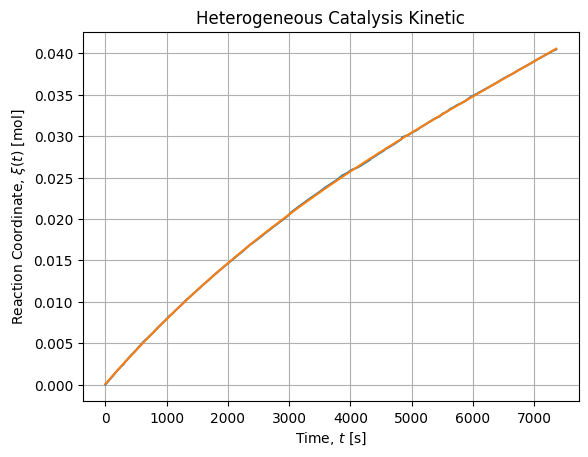

In [49]:
fig, axe = plt.subplots()
axe.plot(df["t"], df["xi"])
axe.plot(df["t"], y5Phat)
axe.set_title("Heterogeneous Catalysis Kinetic")
axe.set_xlabel(r"Time, $t$ $[\mathrm{s}]$")
axe.set_ylabel(r"Reaction Coordinate, $\xi(t)$ $[\mathrm{mol}]$")
axe.grid()

In [50]:
dCdt5 = np.diff(y5Phat) / df["t"].diff().values[1:] / V

In [51]:
X5 = df[["B/A"]].values[1:,:]
y5 = 1. / dCdt5

In [52]:
OLS5 = LinearRegression(fit_intercept=True).fit(X5, y5)

In [53]:
popt5 = solveOLS4(OLS5)
popt5

array([4.66957688e-02, 7.41708729e+01])

In [54]:
df["xi5"] = model1(df["t"], *popt5)

In [55]:
score5 = metrics.r2_score(df["xi"], df["xi5"])
score5

0.9999315752133799

In [56]:
chi25 = np.sum(((df["xi"] - df["xi5"]) / df["xi5"]) ** 2)
chi25

np.float64(1.0042530867706132)

In [57]:
results.append({
    "name": "OLS LW Poly Interp",
    "k1": popt5[0],
    "k2": popt5[1],
    "r2": score5,
    "chi2": chi25
})

### LW Smoothing

### LW Manual

In [58]:
df2 = pd.read_excel("cathet.xlsx", sheet_name="Manual")

In [59]:
df2["1/v"] *= V

In [60]:
df2.loc[0, "1/v"] = 22.45
df2.loc[4, "1/v"] = 32.45

In [61]:
df2["1/v"] *= 1.1

In [62]:
X7 = df2[["bP/bR"]].values
y7 = df2["1/v"].values

In [63]:
OLS7 = LinearRegression(fit_intercept=True).fit(X7, y7)

In [64]:
popt7 = solveOLS4(OLS7)
popt7

array([4.78141520e-02, 7.65547585e+01])

In [65]:
df["xi7"] = model1(df["t"], *popt7)

In [66]:
score7 = metrics.r2_score(df["xi"], df["xi7"])
score7

0.9996181966091182

In [67]:
chi27 = np.sum(((df["xi"] - df["xi7"]) / df["xi7"]) ** 2)
chi27

np.float64(1.0241376987090989)

In [68]:
results.append({
    "name": "OLS LW Manual",
    "k1": popt7[0],
    "k2": popt7[1],
    "r2": score7,
    "chi2": chi27
})

## Synthesis

In [69]:
results = pd.DataFrame(results)

In [70]:
results

,name,k1,k2,r2,chi2
0,NLLS Model,0.047406,77.346960,0.999956,1.008935
1,NLLS Reversed Model,0.047536,78.005591,0.999956,1.010749
2,OLS Reversed Model,0.047536,78.005591,0.999956,1.010749
3,OLS LW 1st diff,0.047019,78.245130,0.999623,1.011802
4,OLS LW Poly Interp,0.046696,74.170873,0.999932,1.004253
5,OLS LW Manual,0.047814,76.554758,0.999618,1.024138


### Error Surface

In [71]:
k1lin = np.linspace(4.4e-2, 5.0e-2, 200)
k2lin = np.linspace(70, 85, 200)

In [72]:
K1, K2 = np.meshgrid(k1lin, k2lin)

In [98]:
def factory(t, xi):
    @np.vectorize
    def wrapped(k1, k2):
        return metrics.mean_squared_error(xi, model1(t, k1, k2))
    return wrapped

In [99]:
loss = factory(df["t"], df["xi"])

In [100]:
L = loss(K1, K2)

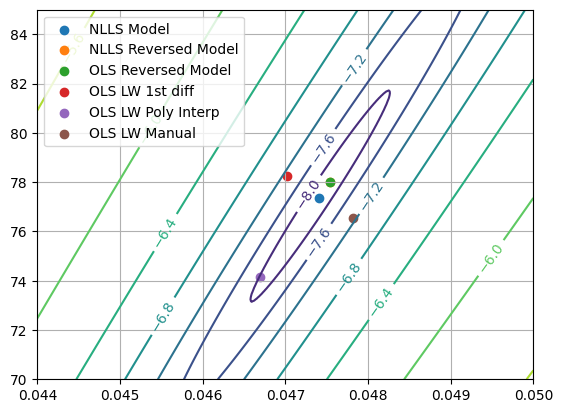

In [103]:
fig, axe = plt.subplots()
C = axe.contour(K1, K2, np.log10(L))
axe.clabel(C, C.levels)
for i, row in results.iterrows():
    axe.scatter(row.k1, row.k2, label=row["name"])
axe.legend(loc="upper left")
axe.grid()